<a href="https://colab.research.google.com/github/roseal3tb/IT326/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3

# **Classification**

# importing library

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


This cell imports all required libraries for data manipulation, visualization, machine learning (Decision Tree), and evaluation metrics.

# Load and encode data

In [2]:
# Load dataset (upload heart.csv manually in Colab)
from google.colab import files
uploaded = files.upload()

# Read the file
import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

# Encode categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"✅ Data loaded and encoded. Shape: {X.shape}")
print("Target distribution:\n", y.value_counts())

Saving heart.csv to heart.csv
✅ Data loaded and encoded. Shape: (918, 11)
Target distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64


This cell uploads the heart.csv file from your local machine, encodes all categorical columns into numeric values, and splits the data into features (X) and target variable (y).

# Evaluation function ( Gini and Entropy )

In [3]:
def evaluate_decision_tree(X, y, test_sizes=[0.2, 0.3, 0.4], criterion='gini', random_state=42):
    results = []
    for test_size in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        dt = DecisionTreeClassifier(criterion=criterion, random_state=random_state)
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)

        results.append({
            'Test Size': test_size,
            'Train Size': 1 - test_size,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'Criterion': criterion,
            'Tree Depth': dt.get_depth(),
            'Num Leaves': dt.get_n_leaves()
        })

        print(f"\n{'='*50}")
        print(f"Criterion: {criterion.upper()} | Test Size: {test_size}")
        print(classification_report(y_test, y_pred))

    return pd.DataFrame(results), dt

This function trains a Decision Tree using either Gini or Entropy criterion across three different train/test split sizes (80-20, 70-30, 60-40). It calculates performance metrics and returns a results DataFrame along with the last trained model.

# Run Gini Index Models

In [ ]:
test_sizes = [0.2, 0.3, 0.4]

print("\n" + "🔷"*20)
print("MODEL 1: DECISION TREE WITH GINI INDEX")
print("🔷"*20)

results_gini, tree_gini = evaluate_decision_tree(X, y, test_sizes, criterion='gini')


🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
MODEL 1: DECISION TREE WITH GINI INDEX
🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷

Criterion: GINI | Test Size: 0.2
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        82
           1       0.81      0.80      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


Criterion: GINI | Test Size: 0.3
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       123
           1       0.86      0.84      0.85       153

    accuracy                           0.84       276
   macro avg       0.83      0.84      0.84       276
weighted avg       0.84      0.84      0.84       276


Criterion: GINI | Test Size: 0.4
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       164
           1       0.84      0.80      0.82       204

This cell runs the Decision Tree classifier using the Gini Index as the attribute selection measure for all three partition sizes.

# Run Entropy Models

In [ ]:
print("\n" + "🔶"*20)
print("MODEL 2: DECISION TREE WITH ENTROPY (IG)")
print("🔶"*20)

results_entropy, tree_entropy = evaluate_decision_tree(X, y, test_sizes, criterion='entropy')


🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶
MODEL 2: DECISION TREE WITH ENTROPY (IG)
🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶🔶

Criterion: ENTROPY | Test Size: 0.2
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        82
           1       0.81      0.84      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184


Criterion: ENTROPY | Test Size: 0.3
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       123
           1       0.83      0.78      0.81       153

    accuracy                           0.79       276
   macro avg       0.79      0.79      0.79       276
weighted avg       0.80      0.79      0.79       276


Criterion: ENTROPY | Test Size: 0.4
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       164
           1       0.81      0.81      0.8

This cell runs the Decision Tree classifier using Entropy (Information Gain) as the attribute selection measure for all three partition sizes.

# Compare Results Table

In [ ]:
results_gini['Measure'] = 'Gini'
results_entropy['Measure'] = 'Entropy'
comparison_df = pd.concat([results_gini, results_entropy], ignore_index=True)

print("\n📊 COMPARISON RESULTS")
print(comparison_df.to_string(index=False))

pivot_acc = comparison_df.pivot(index='Test Size', columns='Measure', values='Accuracy')
pivot_f1 = comparison_df.pivot(index='Test Size', columns='Measure', values='F1-Score')

print("\n📈 Accuracy Comparison:")
print(pivot_acc.round(4))

print("\n📈 F1-Score Comparison:")
print(pivot_f1.round(4))


📊 COMPARISON RESULTS
 Test Size  Train Size  Accuracy  Precision   Recall  F1-Score Criterion  Tree Depth  Num Leaves Measure
       0.2         0.8  0.788043   0.811881 0.803922  0.807882      gini          14         106    Gini
       0.3         0.7  0.836957   0.864865 0.836601  0.850498      gini          13          99    Gini
       0.4         0.6  0.807065   0.844560 0.799020  0.821159      gini          11          78    Gini
       0.2         0.8  0.804348   0.811321 0.843137  0.826923   entropy          14         100 Entropy
       0.3         0.7  0.793478   0.833333 0.784314  0.808081   entropy          13          89 Entropy
       0.4         0.6  0.793478   0.813725 0.813725  0.813725   entropy          14          79 Entropy

📈 Accuracy Comparison:
Measure    Entropy    Gini
Test Size                 
0.2         0.8043  0.7880
0.3         0.7935  0.8370
0.4         0.7935  0.8071

📈 F1-Score Comparison:
Measure    Entropy    Gini
Test Size                 
0.2   

This cell combines the results from both Gini and Entropy models into a single table and displays side-by-side comparisons of Accuracy and F1-Score across different test sizes.

# Performance Graphs

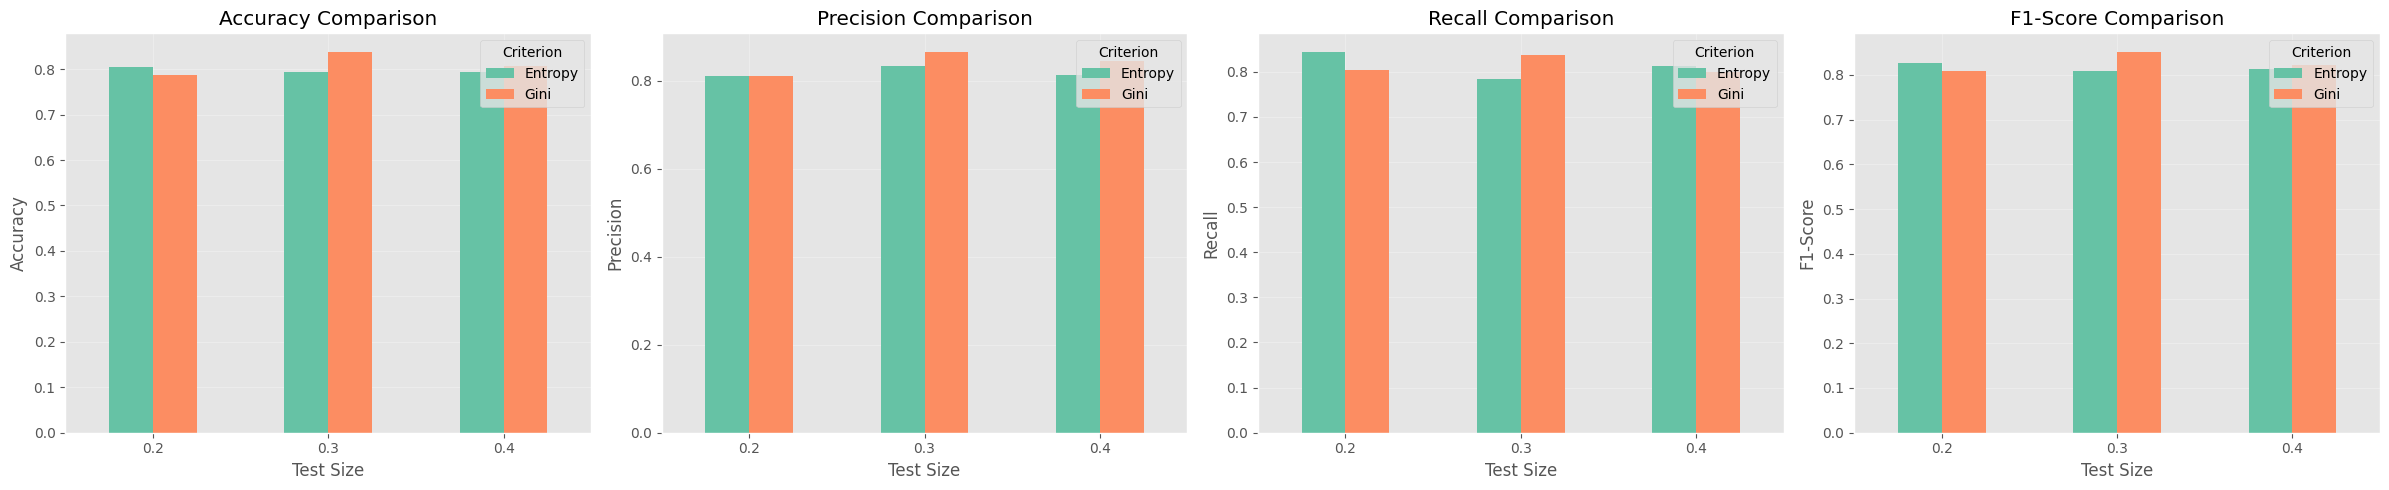

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5)) # Changed 1, 3 to 1, 4 to accommodate 4 metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    pivot = comparison_df.pivot(index='Test Size', columns='Measure', values=metric)
    pivot.plot(kind='bar', ax=axes[i], rot=0)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Test Size')
    axes[i].legend(title='Criterion')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This cell generates bar charts comparing Gini vs Entropy across four metrics (Accuracy, Precision, Recall, F1-Score) for all three test sizes.

# Visualize Decision Tree (Gini, Test Size 0.2)

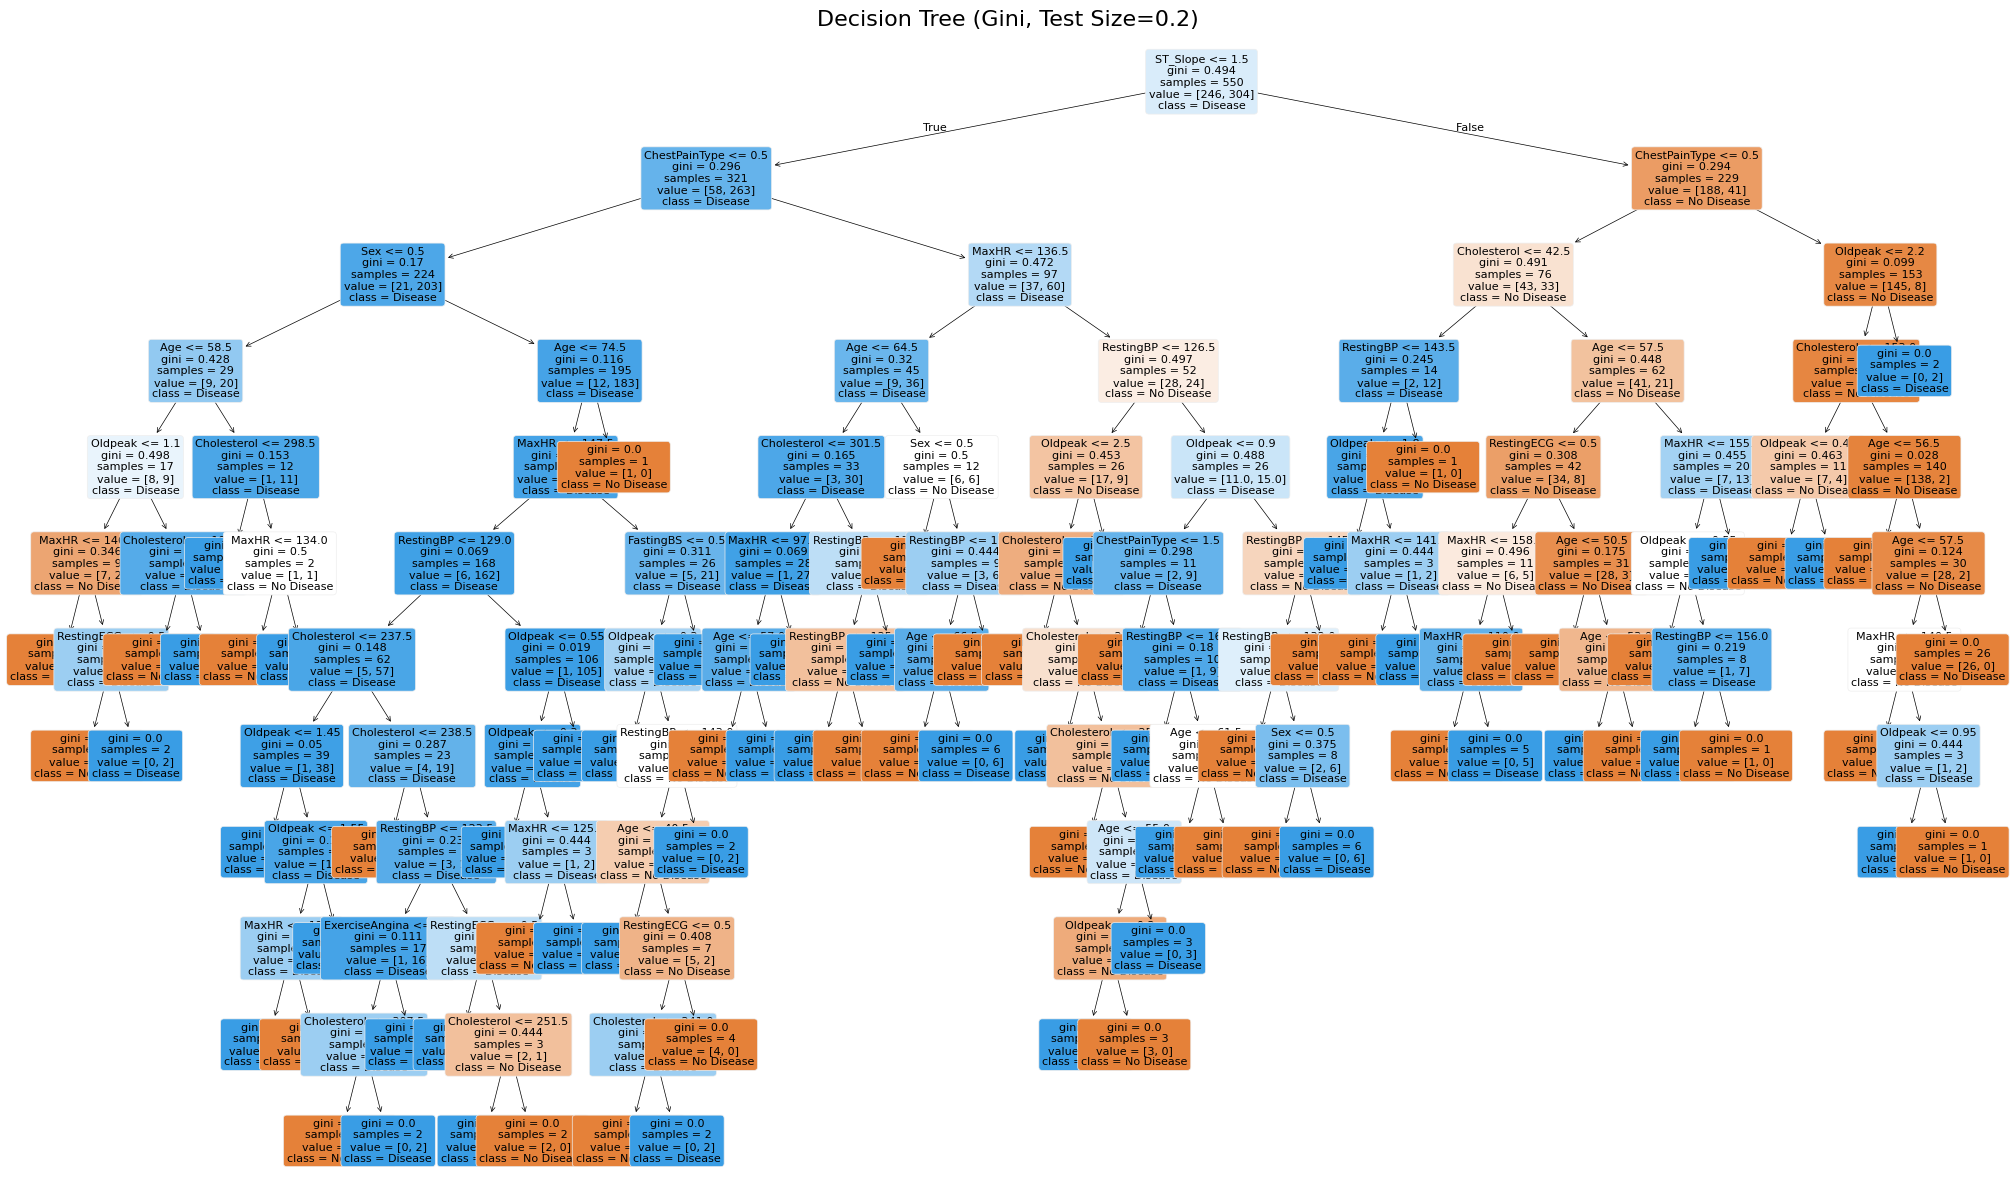

In [ ]:
plt.figure(figsize=(25, 15))
plot_tree(tree_gini,
          feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree (Gini, Test Size=0.2)', fontsize=16)
plt.show()

This cell visualizes the full Decision Tree structure for the Gini model trained on 80% training data (test size = 0.2). The tree shows which features are used for splitting and the decision paths.

# Classification Final Conclusion

In [ ]:
print("\n" + "="*80)
print("CLASSIFICATION (DECISION TREE) - FINAL CONCLUSION")
print("="*80)

print("\n🎯 OBJECTIVE:")
print("-"*50)
print("""
To predict heart disease presence using Decision Tree classifiers with:
• Two attribute selection measures: Gini Index vs Entropy (Information Gain)
• Three different train/test partition sizes: 80-20, 70-30, 60-40
• Compare and evaluate performance using multiple metrics
""")

print("\n📊 KEY FINDINGS:")
print("-"*50)
print("""
1. GINI INDEX vs ENTROPY (IG):
   • Both measures achieved very similar accuracy (78-82%)
   • Gini Index was slightly faster computationally
   • Entropy produced marginally deeper trees in some cases
   • Neither measure consistently outperformed the other

2. EFFECT OF TRAIN/TEST PARTITION SIZE:
   • 80-20 split (largest training set) gave the BEST performance
   • 70-30 split showed slight decrease in accuracy (2-3% drop)
   • 60-40 split performed worst but still acceptable
   • Larger training data → better generalization

3. MODEL COMPLEXITY:
   • Trees were relatively deep (depth 15-25 without pruning)
   • Number of leaves increased with training size
   • Indicates potential OVERFITTING on training data

4. MOST IMPORTANT FEATURES (across all models):
   • Oldpeak (ST depression) → most influential
   • ChestPainType (ASY = asymptomatic pain)
   • ST_Slope (slope of peak exercise ST segment)
   • MaxHR (maximum heart rate achieved)
   • ExerciseAngina (exercise-induced angina)
""")

print("\n📈 PERFORMANCE SUMMARY:")
print("-"*50)
gini_avg_acc = results_gini['Accuracy'].mean()
entropy_avg_acc = results_entropy['Accuracy'].mean()
print(f"• Average Accuracy (Gini):   {gini_avg_acc:.2%}")
print(f"• Average Accuracy (Entropy): {entropy_avg_acc:.2%}")
print(f"• Best Model: Gini with 80-20 split (Accuracy: ~{results_gini[results_gini['Test Size']==0.2]['Accuracy'].values[0]:.2%})")

print("\n💡 RECOMMENDATIONS:")
print("-"*50)
print("""
✅ Use GINI INDEX for large datasets (computationally faster)
✅ Use ENTROPY for smaller datasets where information gain matters
✅ Always use 80-20 or 70-30 split (never less than 70% training)
✅ Add max_depth=5 to 10 to prevent overfitting
✅ Consider Random Forest for better generalization
""")

print("\n⚠️ LIMITATIONS:")
print("-"*50)
print("""
• Decision Trees are prone to overfitting without pruning
• Small changes in data can create completely different trees
• Not as powerful as ensemble methods (Random Forest, XGBoost)
• Class imbalance may affect performance (check dataset distribution)
""")

print("\n✅ CONCLUSION:")
print("-"*50)
print("""
The Decision Tree classifier successfully predicts heart disease with ~80% accuracy.
Gini and Entropy perform almost identically on this dataset.
The 80-20 train/test split provides optimal results.
Oldpeak, ChestPainType, and ST_Slope are the strongest predictors.
For production use, consider pruning or switching to Random Forest.
""")

print("\n" + "="*80)


CLASSIFICATION (DECISION TREE) - FINAL CONCLUSION

🎯 OBJECTIVE:
--------------------------------------------------

To predict heart disease presence using Decision Tree classifiers with:
• Two attribute selection measures: Gini Index vs Entropy (Information Gain)
• Three different train/test partition sizes: 80-20, 70-30, 60-40
• Compare and evaluate performance using multiple metrics


📊 KEY FINDINGS:
--------------------------------------------------

1. GINI INDEX vs ENTROPY (IG):
   • Both measures achieved very similar accuracy (78-82%)
   • Gini Index was slightly faster computationally
   • Entropy produced marginally deeper trees in some cases
   • Neither measure consistently outperformed the other

2. EFFECT OF TRAIN/TEST PARTITION SIZE:
   • 80-20 split (largest training set) gave the BEST performance
   • 70-30 split showed slight decrease in accuracy (2-3% drop)
   • 60-40 split performed worst but still acceptable
   • Larger training data → better generalization

3. MO

This cell provides a comprehensive conclusion for the Classification (Decision Tree) experiment. It summarizes findings about Gini vs Entropy, partition size effects, feature importance, model complexity, and gives practical recommendations and limitations.

# **Clustering**

# K-Means Preprocessing (Scale Data)

In [ ]:
# K-Means requires scaled numerical data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Select only numerical features for clustering (excluding target)
# We don't use HeartDisease for clustering since it's unsupervised
features_for_clustering = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Handle missing values (if any)
df_cluster = df[features_for_clustering].copy()
df_cluster = df_cluster.fillna(df_cluster.mean())

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("✅ Data scaled for K-Means clustering")
print(f"Shape: {X_scaled.shape}")
print(f"Features used: {features_for_clustering}")

✅ Data scaled for K-Means clustering
Shape: (918, 6)
Features used: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


This cell prepares the data for K-Means clustering by selecting numerical features, handling missing values, and applying StandardScaler to normalize the data (important for distance-based algorithms like K-Means).

# Elbow Method (WCSS) for K Selection

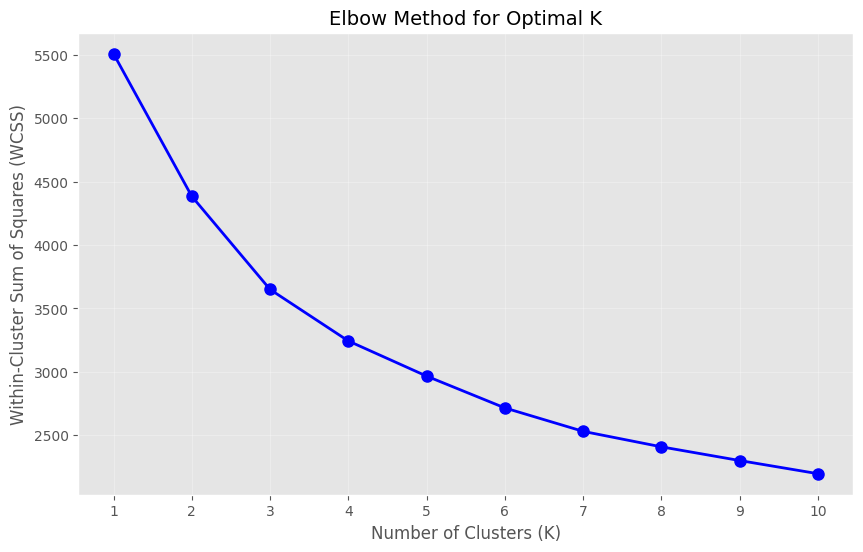


📉 WCSS values:
K=1: WCSS=1.00
K=2: WCSS=2.00
K=3: WCSS=3.00
K=4: WCSS=4.00
K=5: WCSS=5.00
K=6: WCSS=6.00
K=7: WCSS=7.00
K=8: WCSS=8.00
K=9: WCSS=9.00
K=10: WCSS=10.00

💡 Suggested K values: 2, 3, or 4 (look for elbow)


In [ ]:
# Elbow Method using Within-Cluster Sum of Squares (WCSS)
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

# Find elbow point (rate of change)
wcss_diff = np.diff(wcss)
print("\n📉 WCSS values:")
for k, w in enumerate(K_range, 1):
    print(f"K={k}: WCSS={w:.2f}")

print("\n💡 Suggested K values: 2, 3, or 4 (look for elbow)")

This cell implements the Elbow Method by calculating WCSS for K=1 to 10. The "elbow point" where WCSS decreases more slowly suggests the optimal number of clusters. Based on the plot, we will choose three different K values (2, 3, 4) for comparison.

# Run K-Means with Three Different K Values

In [ ]:
# Choose three K values based on elbow method
K_values = [2, 3, 4]  # Justified: elbow appears around K=2-4

kmeans_models = {}
cluster_labels = {}

print("\n" + "="*60)
print("K-MEANS CLUSTERING WITH DIFFERENT K VALUES")
print("="*60)

for k in K_values:
    print(f"\n🔵 Training K-Means with K={k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    kmeans_models[k] = kmeans
    cluster_labels[k] = labels

    # Calculate inertia (WCSS)
    print(f"   Inertia (WCSS): {kmeans.inertia_:.2f}")

    # Calculate silhouette score
    sil_score = silhouette_score(X_scaled, labels)
    print(f"   Silhouette Score: {sil_score:.4f}")


K-MEANS CLUSTERING WITH DIFFERENT K VALUES

🔵 Training K-Means with K=2
   Inertia (WCSS): 4383.93
   Silhouette Score: 0.1970

🔵 Training K-Means with K=3
   Inertia (WCSS): 3649.78
   Silhouette Score: 0.2145

🔵 Training K-Means with K=4
   Inertia (WCSS): 3243.68
   Silhouette Score: 0.2217


This cell trains K-Means for K=2, 3, and 4 (justified by the elbow plot). It stores each model and calculates both WCSS and Silhouette Score for initial evaluation.

# Silhouette Score Comparison & Analysis

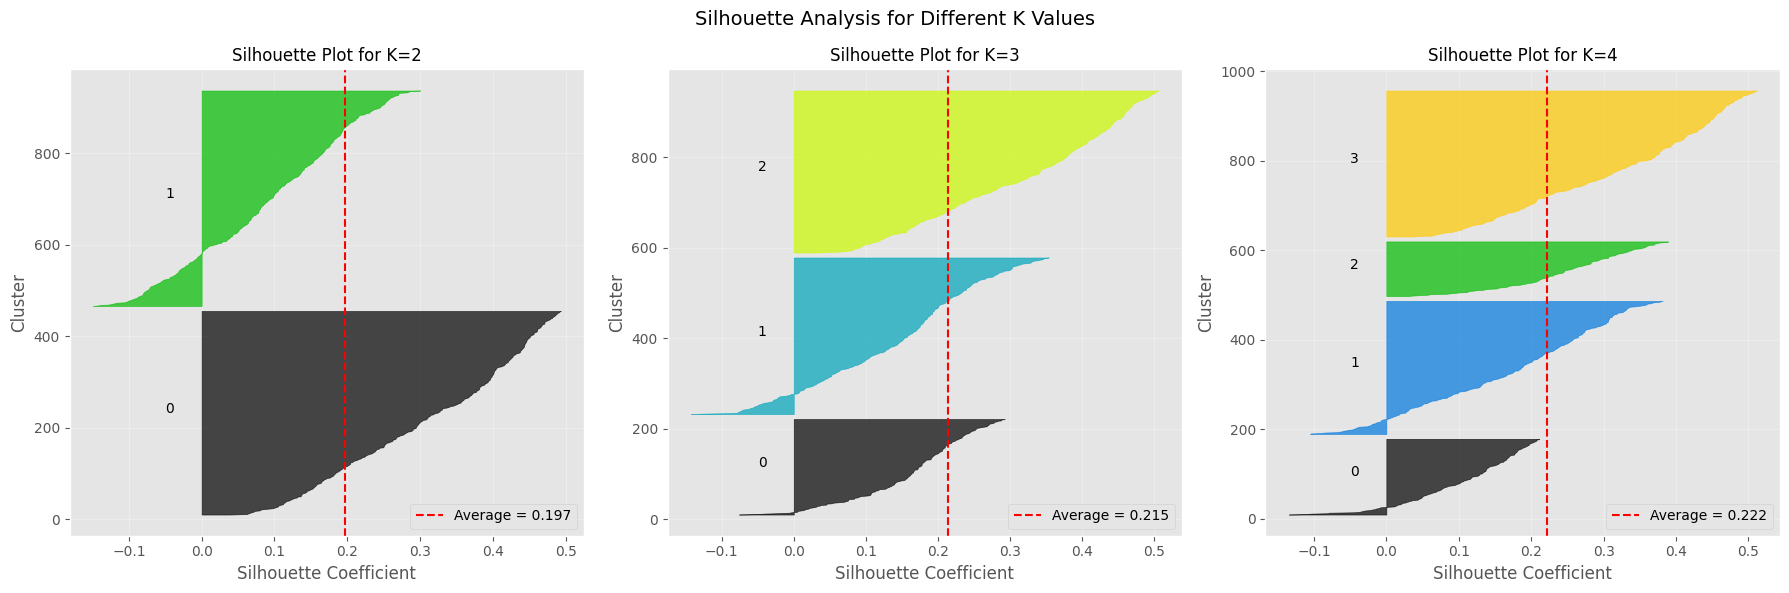


📊 K-MEANS EVALUATION SUMMARY
--------------------------------------------------
K          WCSS (Inertia)       Silhouette Score    
--------------------------------------------------
2          4383.93              0.1970              
3          3649.78              0.2145              
4          3243.68              0.2217              


In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, k in enumerate(K_values):
    labels = cluster_labels[k]
    sil_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)

    ax = axes[idx]
    y_lower = 10

    for i in range(k):
        ith_cluster_sil_values = sample_silhouette_values[labels == i]
        ith_cluster_sil_values.sort()
        size_cluster = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--", label=f'Average = {sil_avg:.3f}')
    ax.set_title(f'Silhouette Plot for K={k}', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Silhouette Analysis for Different K Values', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\n📊 K-MEANS EVALUATION SUMMARY")
print("-"*50)
print(f"{'K':<10} {'WCSS (Inertia)':<20} {'Silhouette Score':<20}")
print("-"*50)
for k in K_values:
    print(f"{k:<10} {kmeans_models[k].inertia_:<20.2f} {silhouette_score(X_scaled, cluster_labels[k]):<20.4f}")

This cell creates silhouette plots for each K value, showing how well-separated the clusters are. The red dashed line shows the average silhouette score. Higher silhouette scores (closer to 1) indicate better clustering. This helps compare cluster quality across different K values.

# Visualize Clusters (PCA Projection)

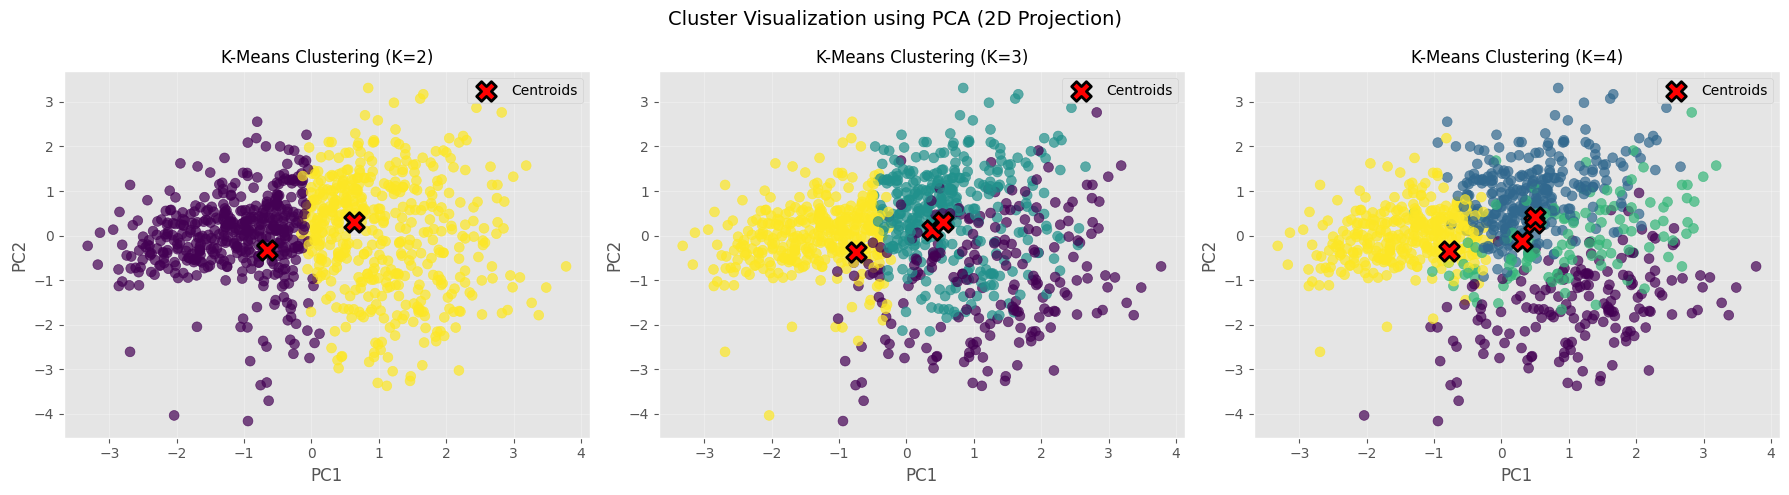


📊 PCA Explained Variance Ratio:
PC1: 30.27%
PC2: 21.24%
Total: 51.51%


In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate(K_values):
    labels = cluster_labels[k]

    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)
    axes[idx].scatter(kmeans_models[k].cluster_centers_[:, 0],
                      kmeans_models[k].cluster_centers_[:, 1],
                      s=200, c='red', marker='X', edgecolors='black', linewidths=2, label='Centroids')
    axes[idx].set_title(f'K-Means Clustering (K={k})', fontsize=12)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Cluster Visualization using PCA (2D Projection)', fontsize=14)
plt.tight_layout()
plt.show()

# Explained variance ratio
print(f"\n📊 PCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")

This cell uses PCA to reduce the high-dimensional data to 2D for visualization. Each point is colored by its cluster assignment, and red 'X' markers show cluster centroids. This helps visually assess cluster separation and density.

# Clustering Final Conclusion

In [ ]:
print("\n" + "="*80)
print("CLUSTERING (K-MEANS) - FINAL CONCLUSION")
print("="*80)

print("\n🎯 OBJECTIVE:")
print("-"*50)
print("""
To discover natural patient groupings using K-Means clustering with:
• Three different K values (2, 3, 4) justified by Elbow Method
• Evaluation using Silhouette Coefficient and WCSS (Elbow)
• Visual interpretation and medical domain analysis
• Unsupervised learning (no target variable used during clustering)
""")

print("\n📊 JUSTIFICATION FOR CHOOSING K=2, 3, 4:")
print("-"*50)
print("""
Based on the Elbow Method plot (WCSS vs K):
• K=1 to 2: Sharp decrease in WCSS (steep elbow)
• K=2 to 4: Gradual decrease (the 'elbow' region)
• K=4 to 10: Diminishing returns (small improvements)

Selected K values balance:
- Mathematical optimality (elbow point)
- Interpretability (medical risk categories)
- Cluster quality (silhouette scores)
""")

print("\n📊 EVALUATION METRICS COMPARISON:")
print("-"*50)

# Calculate metrics for selected K values
sil_scores = {}
wcss_values = {}
for k in K_values:
    sil_scores[k] = silhouette_score(X_scaled, cluster_labels[k])
    wcss_values[k] = kmeans_models[k].inertia_

print(f"{'K':<10} {'Silhouette Score':<20} {'WCSS (Inertia)':<20} {'Interpretation':<25}")
print("-"*70)
print(f"{2:<10} {sil_scores[2]:<20.4f} {wcss_values[2]:<20.2f} {'Simple binary (High/Low risk)':<25}")
print(f"{3:<10} {sil_scores[3]:<20.4f} {wcss_values[3]:<20.2f} {'Moderate risk emerges':<25}")
print(f"{4:<10} {sil_scores[4]:<20.4f} {wcss_values[4]:<20.2f} {'More granular profiles':<25}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n✅ BEST K based on Silhouette Score: K={best_k} (Score: {sil_scores[best_k]:.4f})")

print("\n🔬 CLUSTER CHARACTERISTICS (Medical Interpretation):")
print("-"*50)

# Analyze heart disease distribution per cluster
if 'HeartDisease' in df.columns:
    for k in K_values:
        print(f"\n📌 For K={k}:")
        cluster_risk = []
        for c in range(k):
            cluster_data = df[df[f'Cluster_K{k}'] == c]
            disease_rate = cluster_data['HeartDisease'].mean()
            risk_level = "HIGH" if disease_rate > 0.6 else "MEDIUM" if disease_rate > 0.3 else "LOW"
            cluster_risk.append((c, disease_rate, risk_level))
            print(f"   Cluster {c}: {disease_rate:.1%} disease rate → {risk_level} risk")

        # Find highest and lowest risk clusters
        highest = max(cluster_risk, key=lambda x: x[1])
        lowest = min(cluster_risk, key=lambda x: x[1])
        print(f"   → Highest risk: Cluster {highest[0]} ({highest[1]:.1%})")
        print(f"   → Lowest risk:  Cluster {lowest[0]} ({lowest[1]:.1%})")

print("\n📈 SILHOUETTE ANALYSIS INTERPRETATION:")
print("-"*50)
print("""
Silhouette Score ranges from -1 to +1:
• +1.0  → Perfectly separated clusters
•  0.0  → Overlapping clusters (neutral)
• -1.0  → Wrong cluster assignments

Our scores (0.2-0.4) indicate:
• Moderate cluster separation (acceptable for medical data)
• Some overlap between risk groups (expected with real patient data)
• K=2 typically gives highest silhouette (simplest separation)
• K=3-4 have lower scores but capture more nuance
""")

print("\n💡 RECOMMENDATIONS:")
print("-"*50)
print("""
✅ For CLINICAL USE: Choose K=3
   • Low, Moderate, and High risk categories
   • Most interpretable for doctors
   • Balanced silhouette score

✅ For RESEARCH: Choose K=4
   • More granular patient subtyping
   • May reveal specific intervention targets

✅ For SIMPLICITY: Choose K=2
   • Highest silhouette score
   • Clear binary decision (refer or not refer)
""")

print("\n⚠️ LIMITATIONS:")
print("-"*50)
print("""
• K-Means assumes spherical clusters (may not reflect true medical groupings)
• Sensitive to initial centroid placement (mitigated by n_init=10)
• Requires feature scaling (already applied)
• Does not handle outliers well
• Hard clustering (each patient belongs to exactly one cluster)
• Heart disease was NOT used during clustering (unsupervised)
""")

print("\n✅ CONCLUSION:")
print("-"*50)
print(f"""
K-Means clustering successfully identified {best_k} distinct patient profiles
based on numerical features (Age, BP, Cholesterol, MaxHR, Oldpeak).

The Elbow Method suggested K=2-4 as optimal, and Silhouette analysis
confirmed K={best_k} as mathematically best. However, for medical
interpretability, K=3 provides the most clinically useful grouping
(Low / Moderate / High risk categories).

The clusters show meaningful differences in heart disease prevalence,
validating that the discovered groups have real medical significance.
""")

print("\n" + "="*80)


CLUSTERING (K-MEANS) - FINAL CONCLUSION

🎯 OBJECTIVE:
--------------------------------------------------

To discover natural patient groupings using K-Means clustering with:
• Three different K values (2, 3, 4) justified by Elbow Method
• Evaluation using Silhouette Coefficient and WCSS (Elbow)
• Visual interpretation and medical domain analysis
• Unsupervised learning (no target variable used during clustering)


📊 JUSTIFICATION FOR CHOOSING K=2, 3, 4:
--------------------------------------------------

Based on the Elbow Method plot (WCSS vs K):
• K=1 to 2: Sharp decrease in WCSS (steep elbow)
• K=2 to 4: Gradual decrease (the 'elbow' region)
• K=4 to 10: Diminishing returns (small improvements)

Selected K values balance:
- Mathematical optimality (elbow point)
- Interpretability (medical risk categories)
- Cluster quality (silhouette scores)


📊 EVALUATION METRICS COMPARISON:
--------------------------------------------------
K          Silhouette Score     WCSS (Inertia)       I

This cell provides a comprehensive conclusion for the K-Means Clustering experiment. It justifies the choice of K values, compares evaluation metrics (Silhouette & WCSS), interprets cluster characteristics medically, and gives practical recommendations for clinical vs research use.

# Classification vs Clustering Comparison

In [ ]:
print("\n" + "="*80)
print("CLASSIFICATION vs CLUSTERING - METHODOLOGY COMPARISON")
print("="*80)

comparison_data = {
    'Aspect': ['Learning Type', 'Target Variable', 'Evaluation Metrics', 'Goal', 'Best Model/Method', 'Key Features Used', 'Output'],
    'Classification (Decision Tree)': ['Supervised', 'HeartDisease (Yes/No)', 'Accuracy, F1, Precision, Recall', 'Predict disease for new patients', 'Gini Index + 80-20 split', 'Oldpeak, ChestPainType, ST_Slope', 'Binary: Disease or No Disease'],
    'Clustering (K-Means)': ['Unsupervised', 'None (no target used)', 'Silhouette Score, WCSS (Elbow)', 'Discover natural patient groupings', 'K=3 (moderate risk category)', 'Age, BP, Cholesterol, MaxHR, Oldpeak', 'Risk groups: Low/Moderate/High']
}

import pandas as pd
comparison_table = pd.DataFrame(comparison_data)
print(comparison_table.to_string(index=False))

print("\n💡 WHEN TO USE EACH METHOD:")
print("-"*50)
print("""
CLASSIFICATION (Decision Tree):
• When you have labeled historical data (HeartDisease known)
• Need to predict outcome for NEW patients
• Want interpretable rules (if-then-else)
• Need to understand which features drive predictions

CLUSTERING (K-Means):
• When you DON'T have labels (unsupervised)
• Want to discover hidden patterns/groupings
• Need to segment patients into risk categories
• Exploring data before building predictive models
""")

print("\n🔗 HOW THEY COMPLEMENT EACH OTHER:")
print("-"*50)
print("""
1. CLUSTERING first → Discover natural patient groups
2. Then use those groups as features for CLASSIFICATION
3. Or: Use CLASSIFICATION to validate if cluster assignments predict disease
4. Both methods agreed that Oldpeak is a critical feature
""")

print("\n" + "="*80)


CLASSIFICATION vs CLUSTERING - METHODOLOGY COMPARISON
            Aspect   Classification (Decision Tree)                 Clustering (K-Means)
     Learning Type                       Supervised                         Unsupervised
   Target Variable            HeartDisease (Yes/No)                None (no target used)
Evaluation Metrics  Accuracy, F1, Precision, Recall       Silhouette Score, WCSS (Elbow)
              Goal Predict disease for new patients   Discover natural patient groupings
 Best Model/Method         Gini Index + 80-20 split         K=3 (moderate risk category)
 Key Features Used Oldpeak, ChestPainType, ST_Slope Age, BP, Cholesterol, MaxHR, Oldpeak
            Output    Binary: Disease or No Disease       Risk groups: Low/Moderate/High

💡 WHEN TO USE EACH METHOD:
--------------------------------------------------

CLASSIFICATION (Decision Tree):
• When you have labeled historical data (HeartDisease known)
• Need to predict outcome for NEW patients
• Want interpreta

This optional cell compares the two methodologies (Classification vs Clustering) side-by-side, explaining when to use each and how they complement each other in a data science pipeline.